# Elliptic Bitcoin Dataset — Initial Data Exploration

Three files:
- `elliptic_txs_features.csv` — 203,769 transactions × 167 columns (txId, time_step, 165 features)
- `elliptic_txs_classes.csv` — labels: **1**=illicit, **2**=licit, **unknown**
- `elliptic_txs_edgelist.csv` — 234,355 directed edges

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.dpi"] = 120

DATA_DIR = "/Users/vighaneshs/.cache/kagglehub/datasets/ellipticco/elliptic-data-set/versions/1/elliptic_bitcoin_dataset/"


## 1. Load Data

In [2]:
feat_cols = ['txId', 'time_step'] + [f'local_feat_{i}' for i in range(1, 94)] + [f'agg_feat_{i}' for i in range(1, 73)]
df_feat    = pd.read_csv(DATA_DIR + 'elliptic_txs_features.csv', header=None, names=feat_cols)
df_classes = pd.read_csv(DATA_DIR + 'elliptic_txs_classes.csv')
df_edges   = pd.read_csv(DATA_DIR + 'elliptic_txs_edgelist.csv')

print('Features shape :', df_feat.shape)
print('Classes  shape :', df_classes.shape)
print('Edges    shape :', df_edges.shape)

Features shape : (203769, 167)
Classes  shape : (203769, 2)
Edges    shape : (234355, 2)


In [3]:
df = df_feat.merge(df_classes, on='txId', how='left')
df['label'] = df['class'].astype(str).map({'1': 'illicit', '2': 'licit'}).fillna('unknown')
df['label_num'] = df['class'].astype(str).map({'1': 1, '2': 0}).fillna(-1).astype(int)
df[['txId','time_step','class','label']].head()

/var/folders/9x/q2hhdq1x65lfngz0vxlsc8cw0000gn/T/ipykernel_82685/3333113185.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label'] = df['class'].astype(str).map({'1': 'illicit', '2': 'licit'}).fillna('unknown')
/var/folders/9x/q2hhdq1x65lfngz0vxlsc8cw0000gn/T/ipykernel_82685/3333113185.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['label_num'] = df['class'].astype(str).map({'1': 1, '2': 0}).fillna(-1).astype(int)


,txId,time_step,class,label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown


## 2. Class Distribution

label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64

Labeled: 46,564  |  Illicit: 4,545  |  Licit: 42,019  |  Ratio licit:illicit = 9.2:1


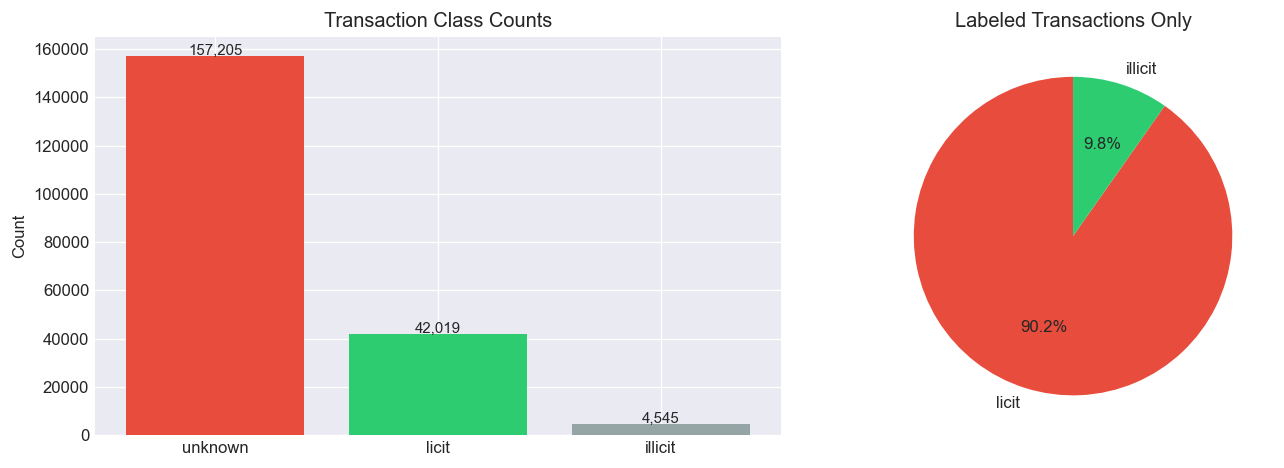

In [4]:
label_counts = df['label'].value_counts()
print(label_counts)
n_ill = (df['label']=='illicit').sum()
n_lic = (df['label']=='licit').sum()
print(f"\nLabeled: {n_ill+n_lic:,}  |  Illicit: {n_ill:,}  |  Licit: {n_lic:,}  |  Ratio licit:illicit = {n_lic/n_ill:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#e74c3c', '#2ecc71', '#95a5a6']
axes[0].bar(label_counts.index, label_counts.values, color=colors)
axes[0].set_title('Transaction Class Counts')
axes[0].set_ylabel('Count')
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f'{val:,}', ha='center', fontsize=9)

labeled = df[df['label'] != 'unknown']['label'].value_counts()
axes[1].pie(labeled.values, labels=labeled.index, autopct='%1.1f%%',
            colors=['#e74c3c','#2ecc71'], startangle=90)
axes[1].set_title('Labeled Transactions Only')
plt.tight_layout()
plt.show()

## 3. Temporal Distribution (49 Time Steps)

Time steps: 1 to 49  (49 steps)


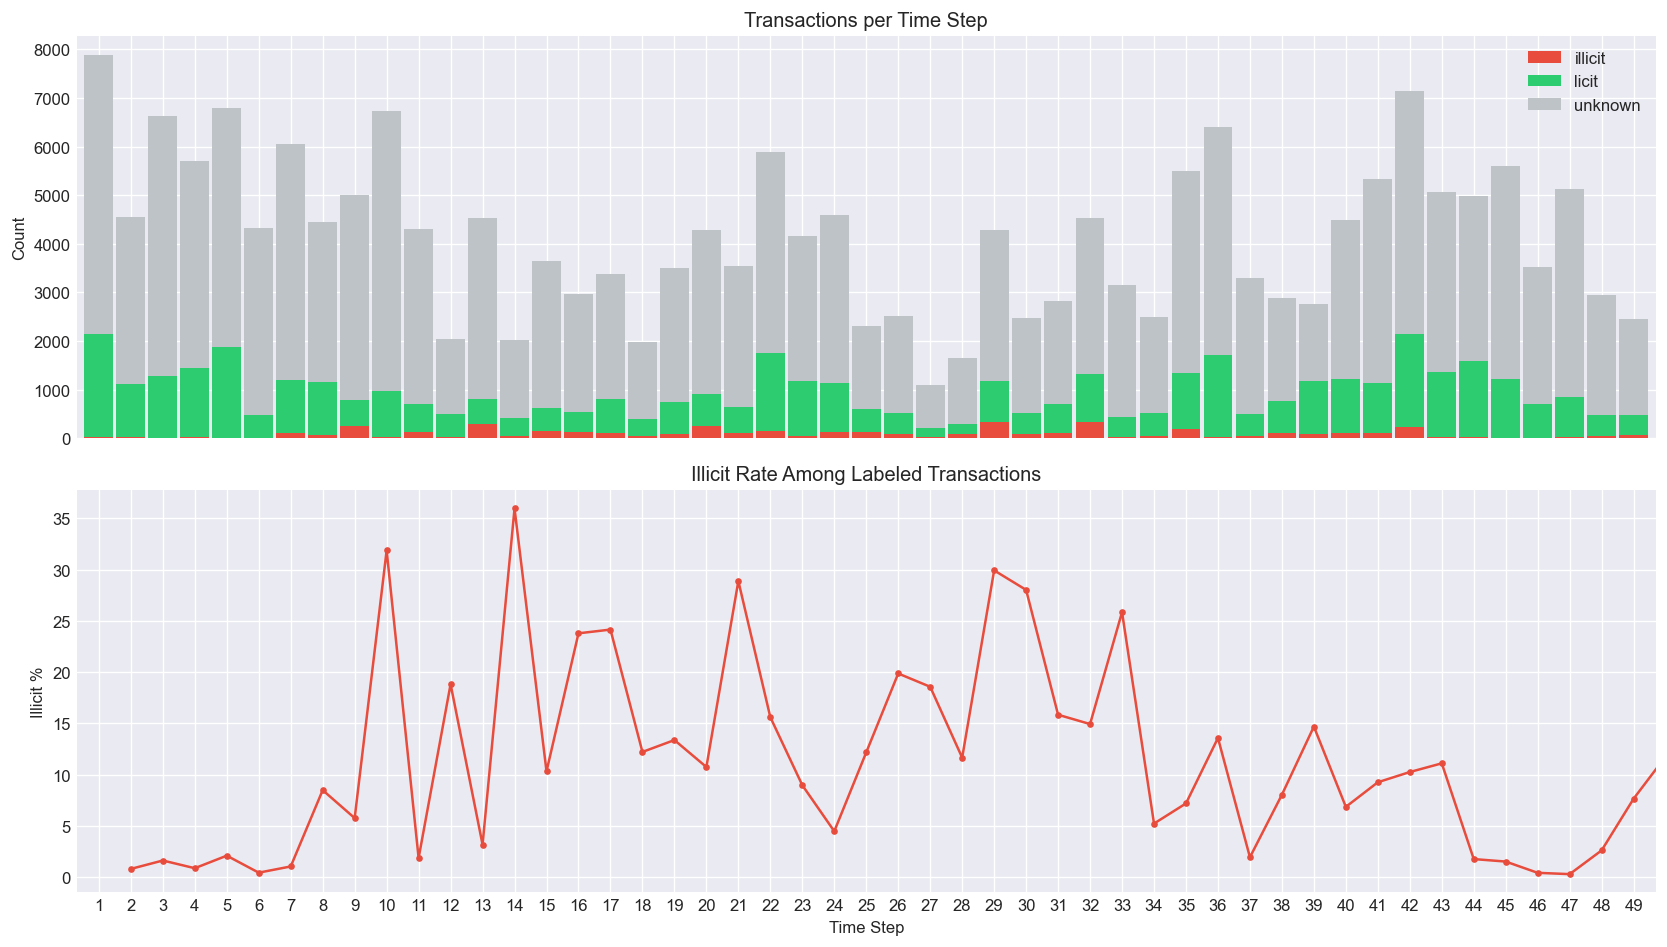

In [5]:
print(f"Time steps: {df['time_step'].min()} to {df['time_step'].max()}  ({df['time_step'].nunique()} steps)")

ts_summary = df.groupby('time_step')['label'].value_counts().unstack(fill_value=0)
for col in ['illicit','licit','unknown']:
    if col not in ts_summary.columns:
        ts_summary[col] = 0

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ts_summary[['illicit','licit','unknown']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#e74c3c','#2ecc71','#bdc3c7'], width=0.9)
axes[0].set_title('Transactions per Time Step')
axes[0].set_ylabel('Count')
axes[0].legend(loc='upper right')

illicit_rate = ts_summary['illicit'] / (ts_summary['illicit'] + ts_summary['licit']).replace(0, np.nan)
axes[1].plot(ts_summary.index, illicit_rate * 100, marker='o', markersize=3, color='#e74c3c')
axes[1].set_title('Illicit Rate Among Labeled Transactions')
axes[1].set_ylabel('Illicit %')
axes[1].set_xlabel('Time Step')
plt.tight_layout()
plt.show()

## 4. Feature Overview

In [6]:
feat_only = [c for c in df.columns if c.startswith('local_feat') or c.startswith('agg_feat')]
print(f"Total features : {len(feat_only)} (93 local + 72 aggregated)")
print(f"Missing values : {df[feat_only].isnull().sum().sum()}")
df[feat_only].describe().T[['mean','std','min','max']].head(10)

Total features : 165 (93 local + 72 aggregated)
Missing values : 0


,mean,std,min,max
local_feat_1,2.231681e-17,1.000002,-0.172983,71.681966
local_feat_2,1.785345e-17,1.000002,-0.210553,73.595052
local_feat_3,3.570689e-17,1.000002,-1.756361,2.683580
local_feat_4,6.890314e-17,1.000002,-0.121970,49.027598
local_feat_5,7.755091e-17,1.000002,-0.063725,260.090707
local_feat_6,5.746578e-17,1.000002,-0.113002,54.565178
local_feat_7,2.566433e-17,1.000002,-0.061584,113.440873
local_feat_8,2.901185e-17,1.000002,-0.163646,73.354565
local_feat_9,4.463361e-17,1.000002,-0.169460,72.318396
local_feat_10,4.658634e-17,1.000002,-0.049707,189.186944


In [15]:
feat_stds = df[feat_only].std().sort_values()
print("All features are pre-normalized (z-score)")
print(f"Std dev range: {feat_stds.min():.8f} to {feat_stds.max():.8f}")
print(f"Unique std values: {feat_stds.nunique()}")
print(f"Low-variance features (std < 0.01): {(feat_stds < 0.01).sum()}")


All features are pre-normalized (z-score)
Std dev range: 1.00000245 to 1.00000245
Unique std values: 4
Low-variance features (std < 0.01): 0


## 5. Feature Distributions: Illicit vs Licit

In [16]:
labeled_df = df[df['label'].isin(['illicit','licit'])].copy()
mean_by_label = labeled_df.groupby('label')[feat_only].mean()
diff = (mean_by_label.loc['illicit'] - mean_by_label.loc['licit']).abs().sort_values(ascending=False)
top_feats = diff.head(15).index.tolist()
print('Top 15 most discriminative features (absolute mean diff):')
print(diff.head(15).round(4).to_string())

Top 15 most discriminative features (absolute mean diff):
local_feat_53    1.2630
local_feat_55    1.0828
local_feat_90    1.0235
local_feat_89    1.0001
local_feat_54    0.9022
local_feat_52    0.8536
local_feat_91    0.8135
local_feat_59    0.7534
local_feat_65    0.7533
local_feat_60    0.7071
local_feat_66    0.7071
local_feat_61    0.6899
local_feat_67    0.6899
agg_feat_21      0.6633
local_feat_25    0.6471


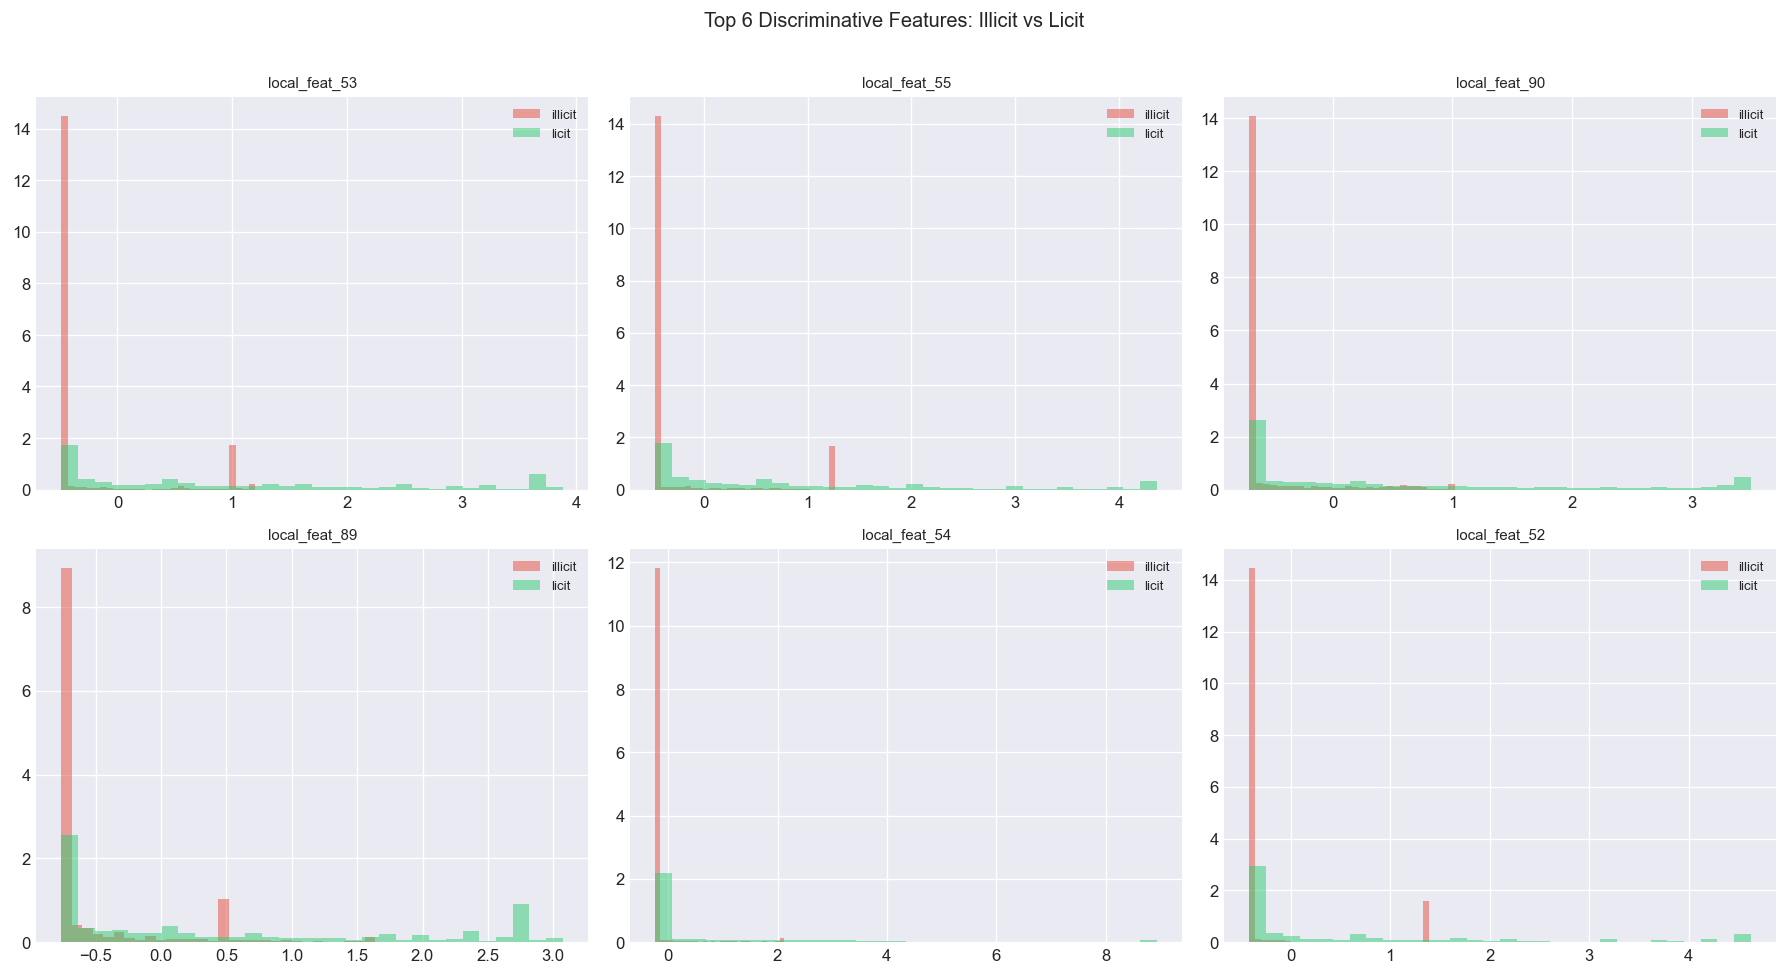

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
colors = {"illicit": "#e74c3c", "licit": "#2ecc71"}

for i, feat in enumerate(top_feats[:6]):
    for lbl in ["illicit", "licit"]:
        subset = labeled_df[labeled_df["label"] == lbl][feat].dropna()
        p1, p99 = subset.quantile(0.01), subset.quantile(0.99)
        if p1 == p99:
            continue
        axes[i].hist(subset.clip(p1, p99), bins=30, alpha=0.5,
                     color=colors[lbl], label=lbl, density=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].legend(fontsize=8)

plt.suptitle("Top 6 Discriminative Features: Illicit vs Licit", y=1.01)
plt.tight_layout()
plt.show()


## 6. Graph / Edge Analysis

In [18]:
print(f"Total edges         : {len(df_edges):,}")
print(f"Unique source nodes : {df_edges['txId1'].nunique():,}")
print(f"Unique target nodes : {df_edges['txId2'].nunique():,}")

out_deg = df_edges['txId1'].value_counts()
in_deg  = df_edges['txId2'].value_counts()
print(f"\nOut-degree  mean={out_deg.mean():.2f}  max={out_deg.max()}  median={int(out_deg.median())}")
print(f"In-degree   mean={in_deg.mean():.2f}   max={in_deg.max()}   median={int(in_deg.median())}")

Total edges         : 234,355
Unique source nodes : 166,345
Unique target nodes : 148,447

Out-degree  mean=1.41  max=472  median=1
In-degree   mean=1.58   max=284   median=1


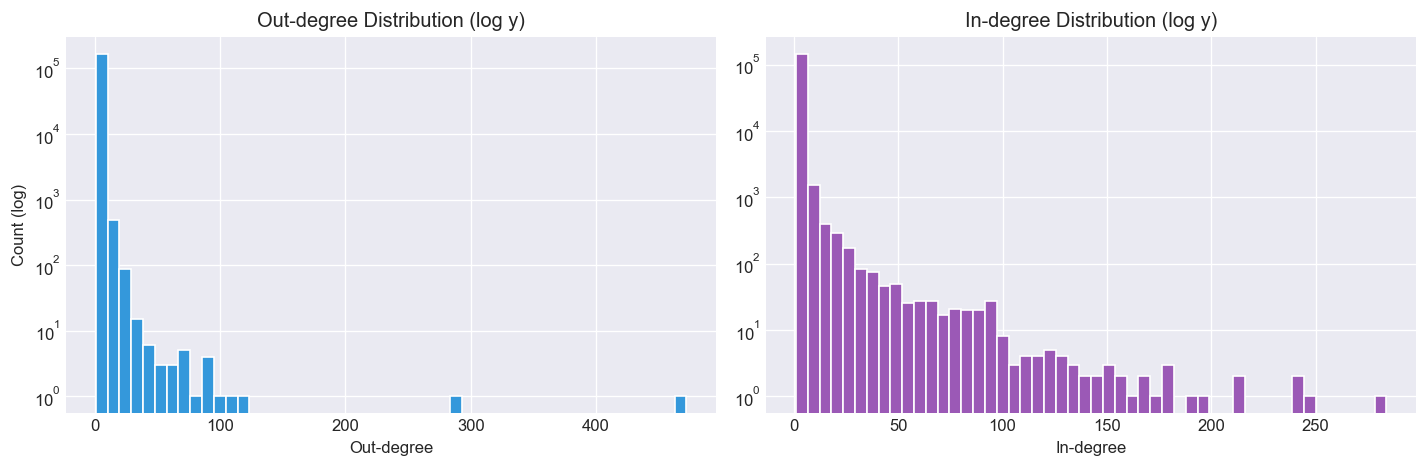

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(out_deg.values, bins=50, color='#3498db', edgecolor='white', log=True)
axes[0].set_title('Out-degree Distribution (log y)')
axes[0].set_xlabel('Out-degree')
axes[0].set_ylabel('Count (log)')

axes[1].hist(in_deg.values, bins=50, color='#9b59b6', edgecolor='white', log=True)
axes[1].set_title('In-degree Distribution (log y)')
axes[1].set_xlabel('In-degree')
plt.tight_layout()
plt.show()

In [20]:
# Label mix of top-1% high out-degree nodes
label_map = df.set_index('txId')['label'].to_dict()
out_deg_df = out_deg.reset_index()
out_deg_df.columns = ['txId', 'out_degree']
out_deg_df['label'] = out_deg_df['txId'].map(label_map).fillna('unknown')
threshold = out_deg_df['out_degree'].quantile(0.99)
high_deg = out_deg_df[out_deg_df['out_degree'] >= threshold]
print(f"Top 1% out-degree threshold: {threshold:.0f}")
print(high_deg['label'].value_counts())

Top 1% out-degree threshold: 6
label
unknown    1353
licit       610
Name: count, dtype: int64


## 7. Correlation Heatmap (Top 20 Features)

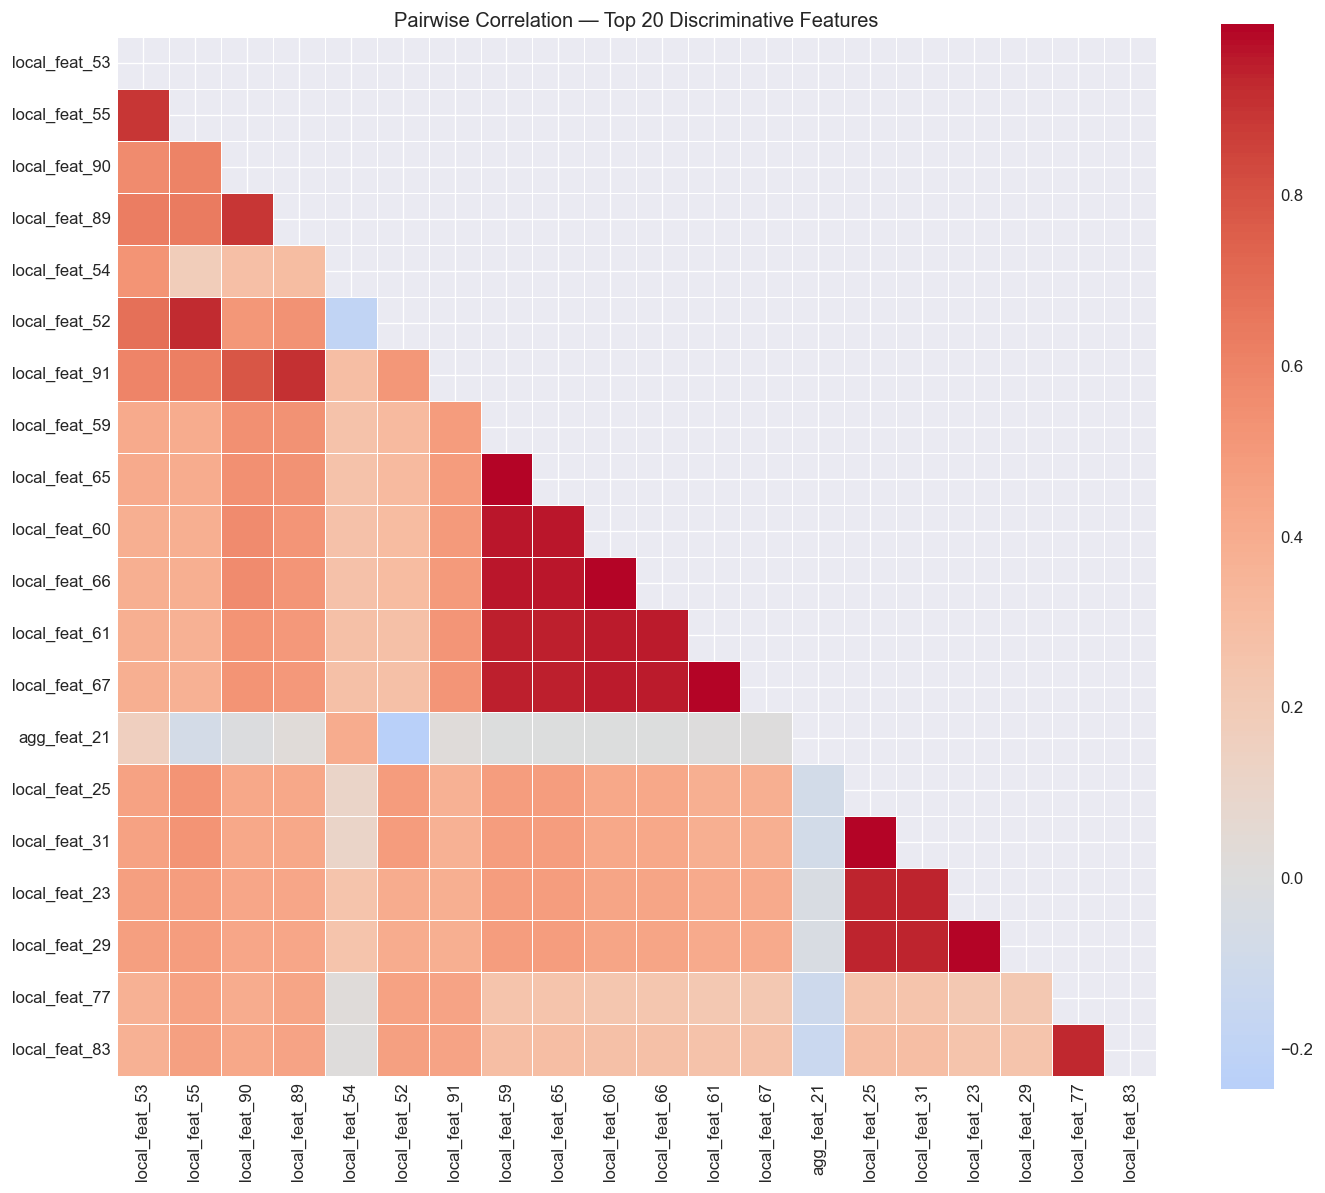

In [24]:
top20 = diff.head(20).index.tolist()
corr = labeled_df[top20].corr()
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
import seaborn as sns
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, annot=False, ax=ax)
ax.set_title('Pairwise Correlation — Top 20 Discriminative Features')
plt.tight_layout()
plt.show()

## 8. Summary

In [25]:
print('=== Dataset Summary ===')
print(f"Transactions      : {len(df):,}")
print(f"Edges             : {len(df_edges):,}")
print(f"Time steps        : {df['time_step'].nunique()} (range 1–49)")
print(f"Features per tx   : 165 (93 local + 72 aggregated)")
print()
print(f"Illicit (class 1) : {n_ill:,}  ({n_ill/len(df)*100:.2f}% of all)")
print(f"Licit   (class 2) : {n_lic:,}  ({n_lic/len(df)*100:.2f}% of all)")
print(f"Unknown           : {(df['label']=='unknown').sum():,}")
print(f"Licit:Illicit ratio (labeled): {n_lic/n_ill:.1f}:1")
print(f"Missing values    : {df[feat_only].isnull().sum().sum()}")

=== Dataset Summary ===
Transactions      : 203,769
Edges             : 234,355
Time steps        : 49 (range 1–49)
Features per tx   : 165 (93 local + 72 aggregated)

Illicit (class 1) : 4,545  (2.23% of all)
Licit   (class 2) : 42,019  (20.62% of all)
Unknown           : 157,205
Licit:Illicit ratio (labeled): 9.2:1
Missing values    : 0
